# 03 - Preprocessing & Build Clean Dataset

Предобработка `final_train.parquet` перед обучением моделей:
- Анализ пропусков, выбросов, распределений
- Умное заполнение пропусков по типу признака
- Winsorization выбросов
- Удаление мультиколлинеарных признаков
- Сохранение параметров для применения к test

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.config import PROCESSED_FILES, PREPROCESS_PARAMS_PATH, REPORTS_DIR

from src.preprocessing import (
    analyze_missing, get_cols_to_drop, fill_missing,
    winsorize_features, remove_multicollinear,
    validate, preprocess_pipeline
)

TARGET = 'TARGET'
ID_COL = 'SK_ID_CURR'

df_raw = pd.read_parquet(PROCESSED_FILES['final_train'])
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} cols')
print(f'Target: {df_raw[TARGET].value_counts().to_dict()}')
print(f'Default rate: {df_raw[TARGET].mean():.2%}')

Loaded: 307,511 rows × 349 cols
Target: {0: 282686, 1: 24825}
Default rate: 8.07%


## 1. Анализ пропусков

In [2]:
missing_stats = analyze_missing(df_raw)
print(f'Колонок с пропусками: {len(missing_stats)}')
print(f'Колонок с >50% пропусков: {(missing_stats["missing_pct"] > 50).sum()}')
print(f'Колонок с >80% пропусков: {(missing_stats["missing_pct"] > 80).sum()}')

missing_stats.head(20)

Колонок с пропусками: 158
Колонок с >50% пропусков: 55
Колонок с >80% пропусков: 1


,missing_count,missing_pct,dtype,nunique
CC_AMT_PAYMENT_TOTAL_MEAN,246451,80.14,float64,56764
AMT_ANNUITY_MEAN,227502,73.98,float64,40578
CC_UTILIZATION_MAX,221475,72.02,float64,56150
CC_UTILIZATION_MEAN,221475,72.02,float64,59105
CC_AMT_CREDIT_LIMIT_MEAN,221475,72.02,float64,8835
CC_AMT_BALANCE_MEAN,220606,71.74,float64,59467
CC_SK_DPD_MEAN,220606,71.74,float64,3606
CC_AMT_DRAWINGS_TOTAL_MEAN,220606,71.74,float64,49079
CC_AMT_BALANCE_MAX,220606,71.74,float64,56722
CC_COUNT,220606,71.74,float64,128


In [3]:
groups = {
    'EXT_SOURCE': [c for c in missing_stats.index if 'EXT_SOURCE' in c],
    'BUREAU': [c for c in missing_stats.index if c.startswith('BUREAU_') or c.startswith('BB_')],
    'PREV': [c for c in missing_stats.index if c.startswith('PREV_')],
    'INS': [c for c in missing_stats.index if c.startswith('INS_')],
    'CC/POS': [c for c in missing_stats.index if c.startswith('CC_') or c.startswith('POS_')],
    'AMT': [c for c in missing_stats.index if c.startswith('AMT_')],
    'DAYS': [c for c in missing_stats.index if c.startswith('DAYS_')],
    'Other': [c for c in missing_stats.index
              if not any(c.startswith(p) for p in ('EXT_SOURCE','BUREAU_','BB_','PREV_','INS_','CC_','POS_','AMT_','DAYS_'))],
}

group_summary = {g: missing_stats.loc[cols, 'missing_pct'].agg(['mean', 'max', 'count'])
                 for g, cols in groups.items() if cols}
pd.DataFrame(group_summary).T.round(1)

,mean,max,count
EXT_SOURCE,12.7,56.4,7.0
BUREAU,19.3,29.4,9.0
PREV,12.6,67.4,19.0
INS,5.2,5.2,11.0
CC/POS,43.1,80.1,25.0
AMT,15.9,74.0,19.0
DAYS,13.4,18.0,9.0
Other,45.0,69.9,59.0


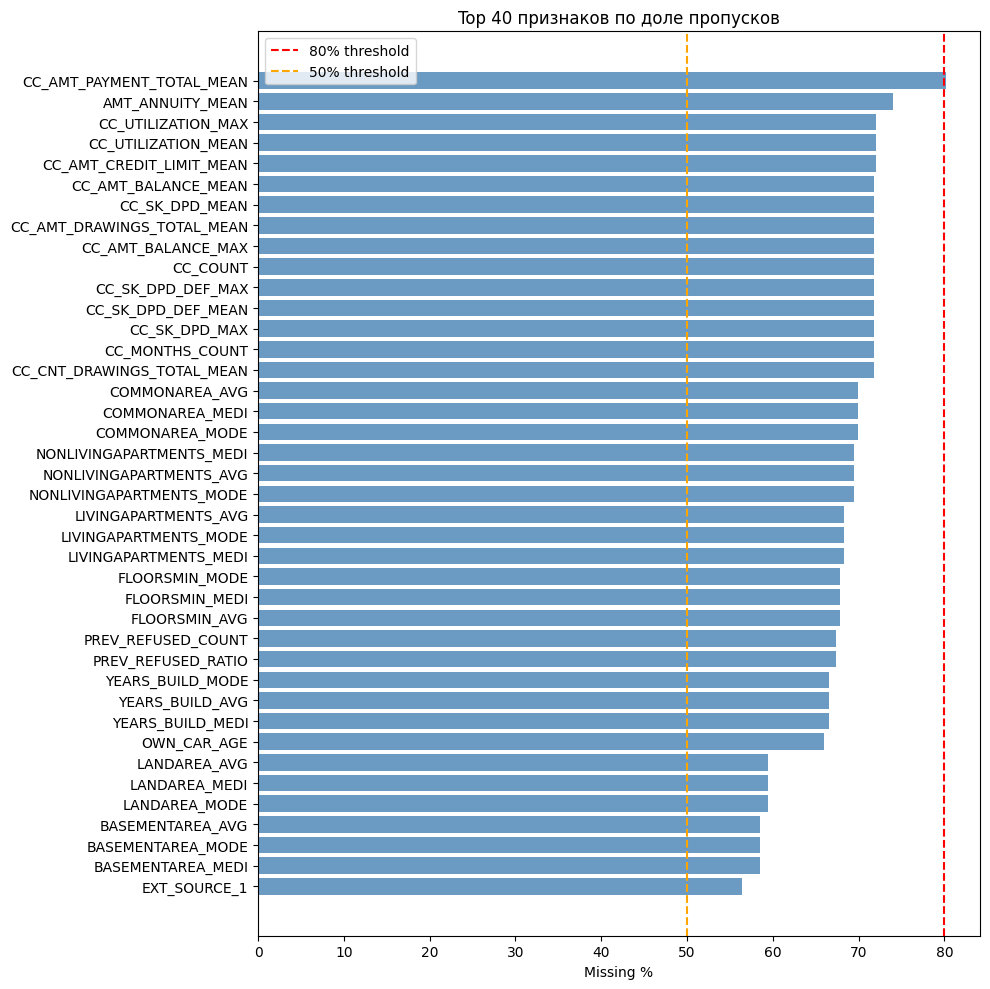

In [4]:
top_missing = missing_stats.head(40)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='steelblue', alpha=0.8)
ax.axvline(80, color='red', linestyle='--', label='80% threshold')
ax.axvline(50, color='orange', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Top 40 признаков по доле пропусков')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Анализ выбросов

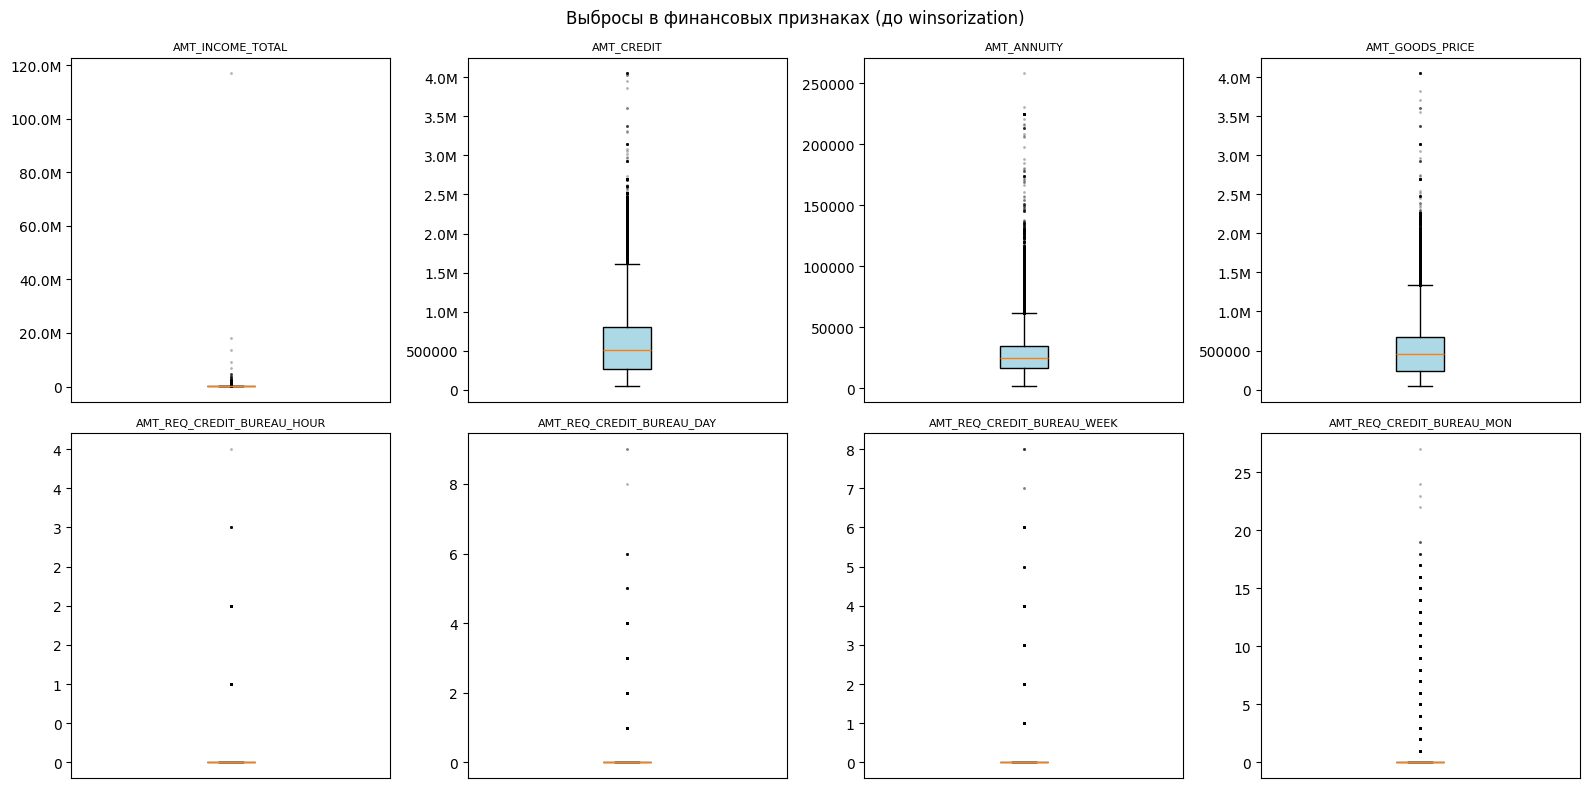

In [5]:
amt_cols = [c for c in df_raw.columns if c.startswith('AMT_') and df_raw[c].dtype != object][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, amt_cols):
    data = df_raw[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               flierprops=dict(marker='.', alpha=0.3, markersize=2))
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x:.0f}'))

plt.suptitle('Выбросы в финансовых признаках (до winsorization)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Анализ распределений — скошенность

Признаков с |skewness| > 1 (медиана лучше): 50
Признаков с |skewness| > 5 (сильный перекос): 50


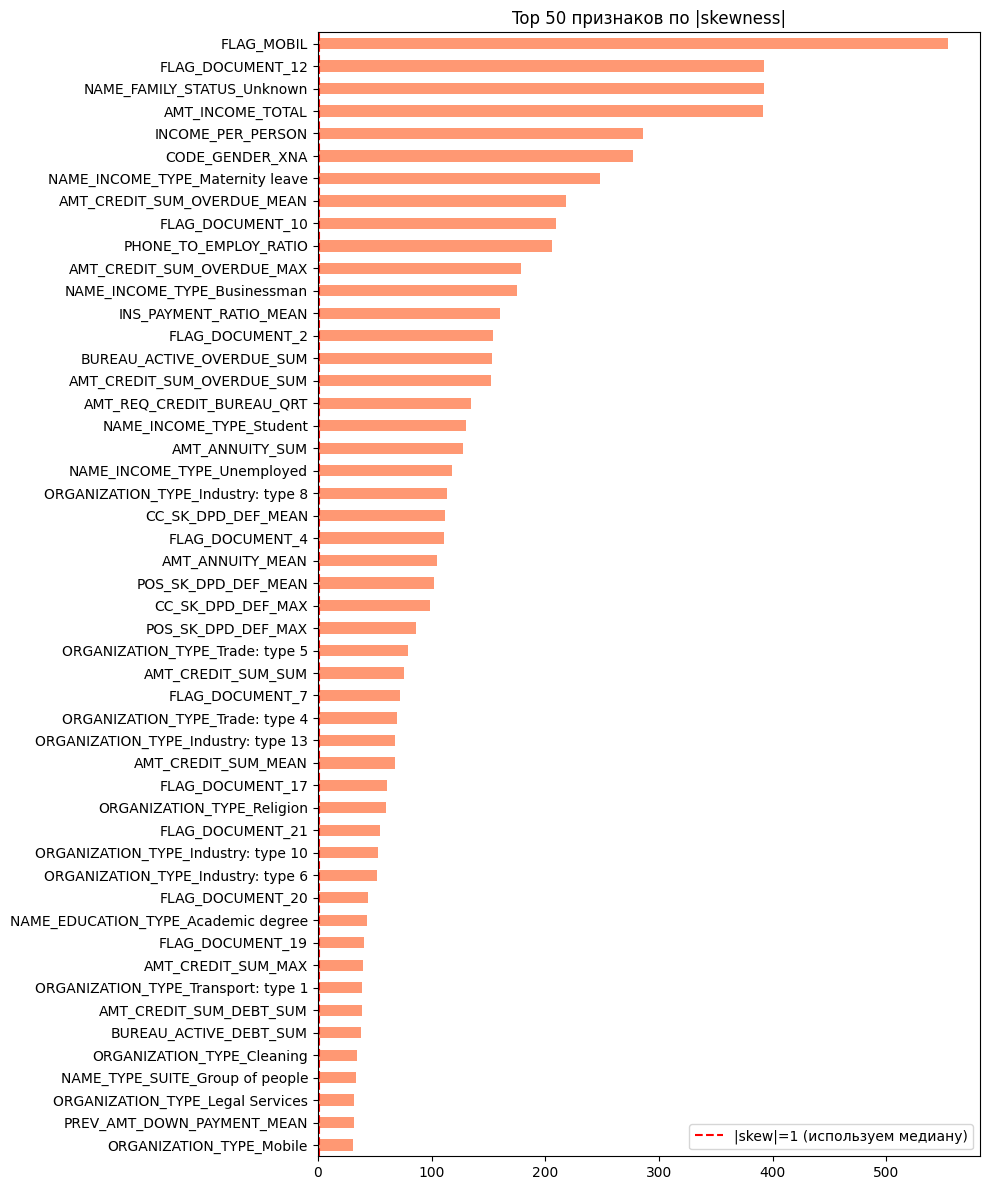

In [6]:
numeric_cols = df_raw.select_dtypes('number').drop(columns=[TARGET, ID_COL], errors='ignore').columns
skewness = df_raw[numeric_cols].skew().abs().sort_values(ascending=False).head(50)

print(f'Признаков с |skewness| > 1 (медиана лучше): {(skewness > 1).sum()}')
print(f'Признаков с |skewness| > 5 (сильный перекос): {(skewness > 5).sum()}')

fig, ax = plt.subplots(figsize=(10, 12))
skewness.sort_values().plot(kind='barh', ax=ax, color='coral', alpha=0.8)
ax.axvline(1, color='red', linestyle='--', label='|skew|=1 (используем медиану)')
ax.set_title('Top 50 признаков по |skewness|')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'skewness.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Корреляционная матрица

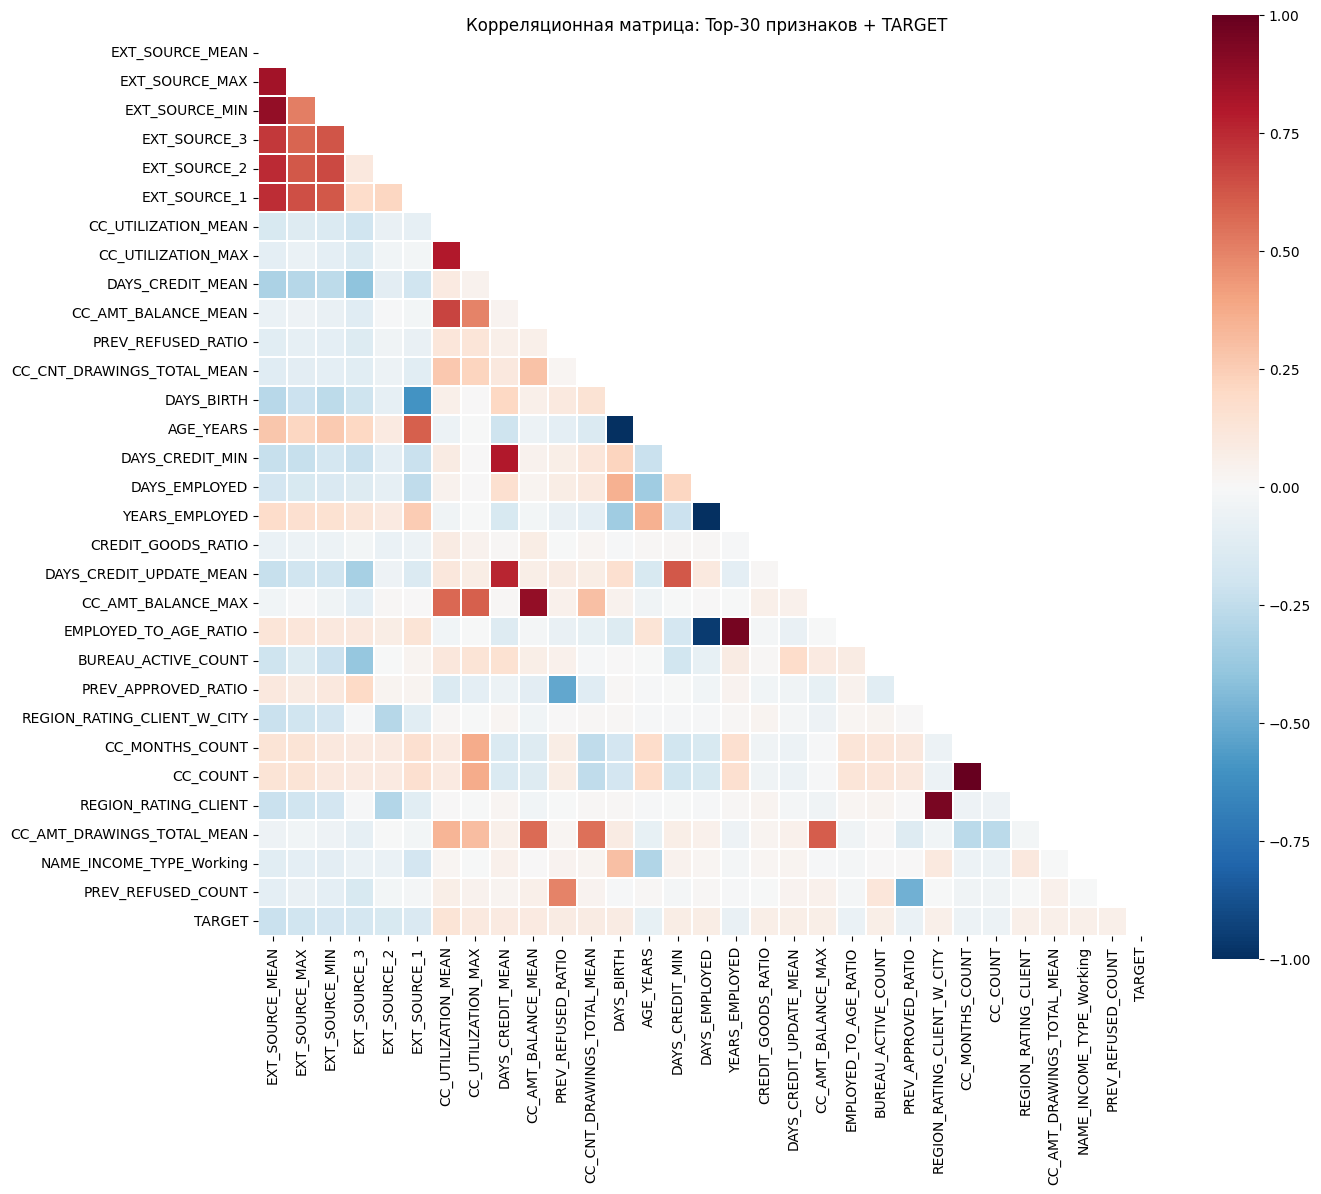

In [7]:
top_corr_cols = (
    df_raw[numeric_cols]
    .corrwith(df_raw[TARGET])
    .abs()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

corr_matrix = df_raw[top_corr_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.3,
)
ax.set_title('Корреляционная матрица: Top-30 признаков + TARGET')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Применение предобработки

In [8]:
print('Запускаем preprocess_pipeline...')
df_clean, preprocess_params = preprocess_pipeline(df_raw, target_col=TARGET, mode='train')

print(f'\nРезультат:')
print(f'  Было:    {df_raw.shape[1]} признаков')
print(f'  Стало:   {df_clean.shape[1]} признаков')
print(f'  Удалено (лишние):  {len(preprocess_params["cols_to_drop"])} колонок')
print(f'  Удалено (мульти):  {len(preprocess_params["multicollinear_dropped"])} колонок')
print(f'  scale_pos_weight для LightGBM: {preprocess_params["scale_pos_weight"]}')

Запускаем preprocess_pipeline...

Результат:
  Было:    349 признаков
  Стало:   211 признаков
  Удалено (лишние):  92 колонок
  Удалено (мульти):  49 колонок
  scale_pos_weight для LightGBM: 11.3872


## 6. Мультиколлинеарность

In [9]:
mc_dropped = preprocess_params['multicollinear_dropped']
print(f'Удалено мультиколлинеарных признаков: {len(mc_dropped)}')
if mc_dropped:
    print('Список:')
    for col in sorted(mc_dropped):
        print(f'  - {col}')

Удалено мультиколлинеарных признаков: 49
Список:
  - AGE_YEARS
  - AMT_CREDIT
  - AMT_CREDIT_SUM_DEBT_MAX
  - AMT_CREDIT_SUM_OVERDUE_MEAN
  - AMT_CREDIT_SUM_OVERDUE_SUM
  - APARTMENTS_AVG
  - APARTMENTS_MODE
  - BASEMENTAREA_MEDI
  - BASEMENTAREA_MODE
  - BUREAU_ACTIVE_DEBT_SUM
  - CNT_CREDIT_PROLONG_SUM
  - CODE_GENDER_F
  - COMMONAREA_AVG
  - COMMONAREA_MODE
  - DAYS_EMPLOYED
  - ELEVATORS_MEDI
  - ELEVATORS_MODE
  - EMPLOYED_TO_AGE_RATIO
  - ENTRANCES_MEDI
  - ENTRANCES_MODE
  - FLAG_EMP_PHONE
  - FLAG_OWN_CAR_N
  - FLAG_OWN_REALTY_N
  - FLOORSMAX_MEDI
  - FLOORSMAX_MODE
  - FLOORSMIN_MEDI
  - FLOORSMIN_MODE
  - INS_AMT_INSTALMENT_MEAN
  - LANDAREA_MEDI
  - LANDAREA_MODE
  - LIVINGAPARTMENTS_MEDI
  - LIVINGAPARTMENTS_MODE
  - LIVINGAREA_MEDI
  - LIVINGAREA_MODE
  - NAME_CONTRACT_TYPE_Cash loans
  - NONLIVINGAPARTMENTS_MEDI
  - NONLIVINGAPARTMENTS_MODE
  - NONLIVINGAREA_MEDI
  - NONLIVINGAREA_MODE
  - OBS_60_CNT_SOCIAL_CIRCLE
  - POS_CNT_INSTALMENT_MEAN
  - POS_COUNT
  - POS_SK_DPD_M

## 7. Финальная валидация

In [10]:
issues = validate(df_clean, original_rows=len(df_raw))

if not issues:
    print('Валидация пройдена: нет пропусков, inf, константных колонок, строки сохранены')
else:
    print('Проблемы:')
    for k, v in issues.items():
        print(f'  {k}: {v}')

print(f'\nФинальный датасет: {df_clean.shape[0]:,} строк × {df_clean.shape[1]:,} признаков')
print(f'TARGET сохранён: {df_clean[TARGET].value_counts().to_dict()}')

Валидация пройдена: нет пропусков, inf, константных колонок, строки сохранены

Финальный датасет: 307,511 строк × 211 признаков
TARGET сохранён: {0: 282686, 1: 24825}


## 8. Сохранение

In [11]:
out_path = Path(PROCESSED_FILES['final_train_clean'])
df_clean.to_parquet(out_path, index=False)
print(f'Saved dataset: {out_path}  ({out_path.stat().st_size/1024/1024:.1f} MB)')

params_path = PREPROCESS_PARAMS_PATH
joblib.dump(preprocess_params, params_path)
print(f'Saved params:  {params_path}')

print(f'\nПараметры для обучения моделей:')
print(f'  scale_pos_weight = {preprocess_params["scale_pos_weight"]}')
print(f'  class_weight     = balanced')
print(f'  feature_cols     = {len(preprocess_params["feature_cols"])} признаков')

Saved dataset: /Users/aitursun/Developer/University/credit-default-prediction/data/processed/final_train_clean.parquet  (87.5 MB)
Saved params:  /Users/aitursun/Developer/University/credit-default-prediction/data/processed/preprocess_params.joblib

Параметры для обучения моделей:
  scale_pos_weight = 11.3872
  class_weight     = balanced
  feature_cols     = 209 признаков


In [12]:
print('=== ИТОГ ===')
print(f'Исходный датасет:  {df_raw.shape}')
print(f'Чистый датасет:    {df_clean.shape}')
print(f'Удалено признаков: {df_raw.shape[1] - df_clean.shape[1]}')
print(f'  - низкая информативность/константы: {len(preprocess_params["cols_to_drop"])}')
print(f'  - мультиколлинеарность: {len(preprocess_params["multicollinear_dropped"])}')
print(f'Пропусков в чистом датасете: {df_clean.isnull().sum().sum()}')
print(f'Доля дефолтов: {df_clean[TARGET].mean():.2%}')
print(f'\nГотово к обучению! Следующий шаг: 04_train_models.ipynb')

=== ИТОГ ===
Исходный датасет:  (307511, 349)
Чистый датасет:    (307511, 211)
Удалено признаков: 138
  - низкая информативность/константы: 92
  - мультиколлинеарность: 49
Пропусков в чистом датасете: 0
Доля дефолтов: 8.07%

Готово к обучению! Следующий шаг: 04_train_models.ipynb


## 9. Обработка тестовых данных

In [13]:
from src.build_dataset import build_dataset

print('Собираем тестовый датасет...')
df_test_raw = build_dataset('test')
print(f'\nfinal_test.parquet → {PROCESSED_FILES["final_test"]}')
print(f'Размер: {df_test_raw.shape[0]:,} строк × {df_test_raw.shape[1]:,} колонок')

Собираем тестовый датасет...
[1/8] Loading application_test.csv...
[2/8] Building application features...
[3/8] Building bureau features...
[4/8] Building previous application features...
[5/8] Building installment payment features...
[6/8] Building POS CASH features...
[7/8] Building credit card features...
[8/8] Joining all features...
Saved → /Users/aitursun/Developer/University/credit-default-prediction/data/processed/final_test.parquet  shape=(48744, 345)

final_test.parquet → /Users/aitursun/Developer/University/credit-default-prediction/data/processed/final_test.parquet
Размер: 48,744 строк × 345 колонок


In [14]:
preprocess_params = joblib.load(PREPROCESS_PARAMS_PATH)
print(f'Загружены параметры из {PREPROCESS_PARAMS_PATH}')
print(f'  cols_to_drop:           {len(preprocess_params["cols_to_drop"])}')
print(f'  multicollinear_dropped: {len(preprocess_params["multicollinear_dropped"])}')
print(f'  feature_cols:           {len(preprocess_params["feature_cols"])}')

print('\nПрименяем preprocess_pipeline к тесту...')
df_test_clean, _ = preprocess_pipeline(df_test_raw, target_col=TARGET, mode='test', params=preprocess_params)

print(f'\nРезультат:')
print(f'  Было:  {df_test_raw.shape[1]} признаков')
print(f'  Стало: {df_test_clean.shape[1]} признаков')

Загружены параметры из /Users/aitursun/Developer/University/credit-default-prediction/data/processed/preprocess_params.joblib
  cols_to_drop:           92
  multicollinear_dropped: 49
  feature_cols:           209

Применяем preprocess_pipeline к тесту...

Результат:
  Было:  345 признаков
  Стало: 210 признаков


In [15]:
issues = validate(df_test_clean, original_rows=len(df_test_raw))
if not issues:
    print('Валидация теста пройдена: нет пропусков, inf, константных колонок')
else:
    print('Проблемы:')
    for k, v in issues.items():
        print(f'  {k}: {v}')

out_path = PROCESSED_FILES['final_test_clean']
df_test_clean.to_parquet(out_path, index=False)
print(f'\nSaved → {out_path}  ({out_path.stat().st_size/1024/1024:.1f} MB)')
print(f'Размер: {df_test_clean.shape[0]:,} строк × {df_test_clean.shape[1]:,} признаков')

Валидация теста пройдена: нет пропусков, inf, константных колонок

Saved → /Users/aitursun/Developer/University/credit-default-prediction/data/processed/final_test_clean.parquet  (16.2 MB)
Размер: 48,744 строк × 210 признаков
